<a href="https://colab.research.google.com/github/lizzietsitsishvili/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%203/Assignment_3_The_Causal_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [11]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

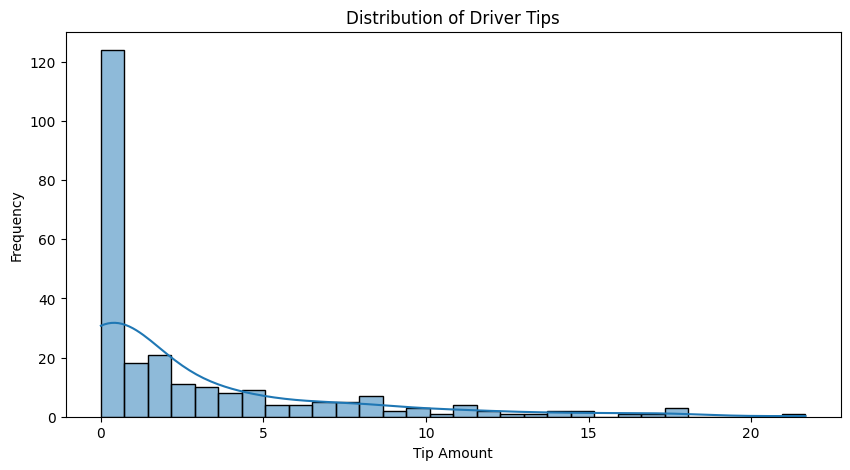

In [12]:
# Visualize the distribution
plt.figure(figsize=(10, 5))
sns.histplot(driver_tips, bins=30, kde=True)
plt.title("Distribution of Driver Tips")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")
plt.show()

In [13]:
# Manual bootstrap of the median
n_boot = 10000
boot_medians = np.empty(n_boot)

for i in range(n_boot):
    sample = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
    boot_medians[i] = np.median(sample)

# 95% bootstrap confidence interval
ci_lower, ci_upper = np.percentile(boot_medians, [2.5, 97.5])

print("Bootstrap 95% CI for the median:")
print("Lower bound:", ci_lower)
print("Upper bound:", ci_upper)

Bootstrap 95% CI for the median:
Lower bound: 0.2653018357387816
Upper bound: 1.3635639228066991


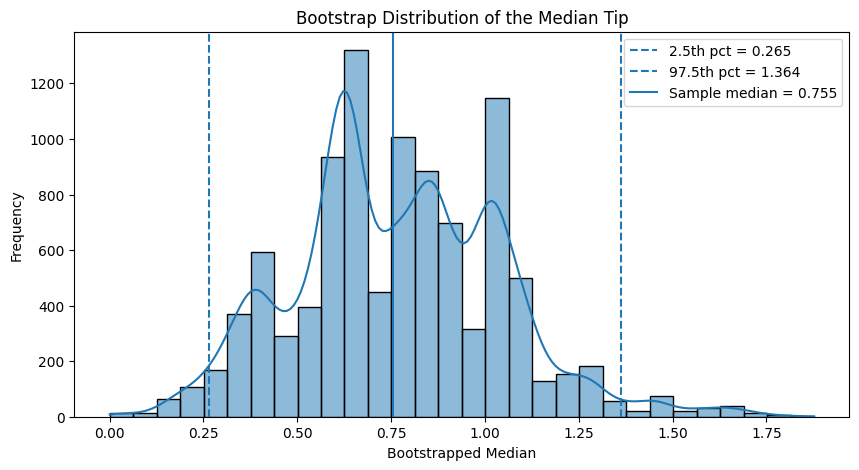

In [14]:
# Plot bootstrap distribution
plt.figure(figsize=(10, 5))
sns.histplot(boot_medians, bins=30, kde=True)
plt.axvline(ci_lower, linestyle="--", label=f"2.5th pct = {ci_lower:.3f}")
plt.axvline(ci_upper, linestyle="--", label=f"97.5th pct = {ci_upper:.3f}")
plt.axvline(np.median(driver_tips), linestyle="-", label=f"Sample median = {np.median(driver_tips):.3f}")
plt.title("Bootstrap Distribution of the Median Tip")
plt.xlabel("Bootstrapped Median")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [15]:
print("Sample median:", np.median(driver_tips))
print(f"95% Bootstrap CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

Sample median: 0.7553316913699188
95% Bootstrap CI: [0.265, 1.364]
